🔥 ScFv vs Claudin Family - OTR Score Heatmap Generator

📊 Veriler yükleniyor...
   ✅ ON-TARGET: 39 model
   ✅ OFF-TARGET: 936 model

🔍 ID'ler çıkarılıyor...

🔗 Veriler birleştiriliyor...
   Toplam veri noktası: 975
   Benzersiz ScFv: 39
   Benzersiz Claudin: 25

📐 Matris oluşturuluyor...
   Matris boyutu: 39 ScFv x 25 Claudin
   ✅ Matris verisi kaydedildi: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/scfv_claudin_matrix_test2.csv

🎨 Heatmap oluşturuluyor...
   ✅ Heatmap kaydedildi: /home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/scfv_claudin_heatmap_test2.pdf


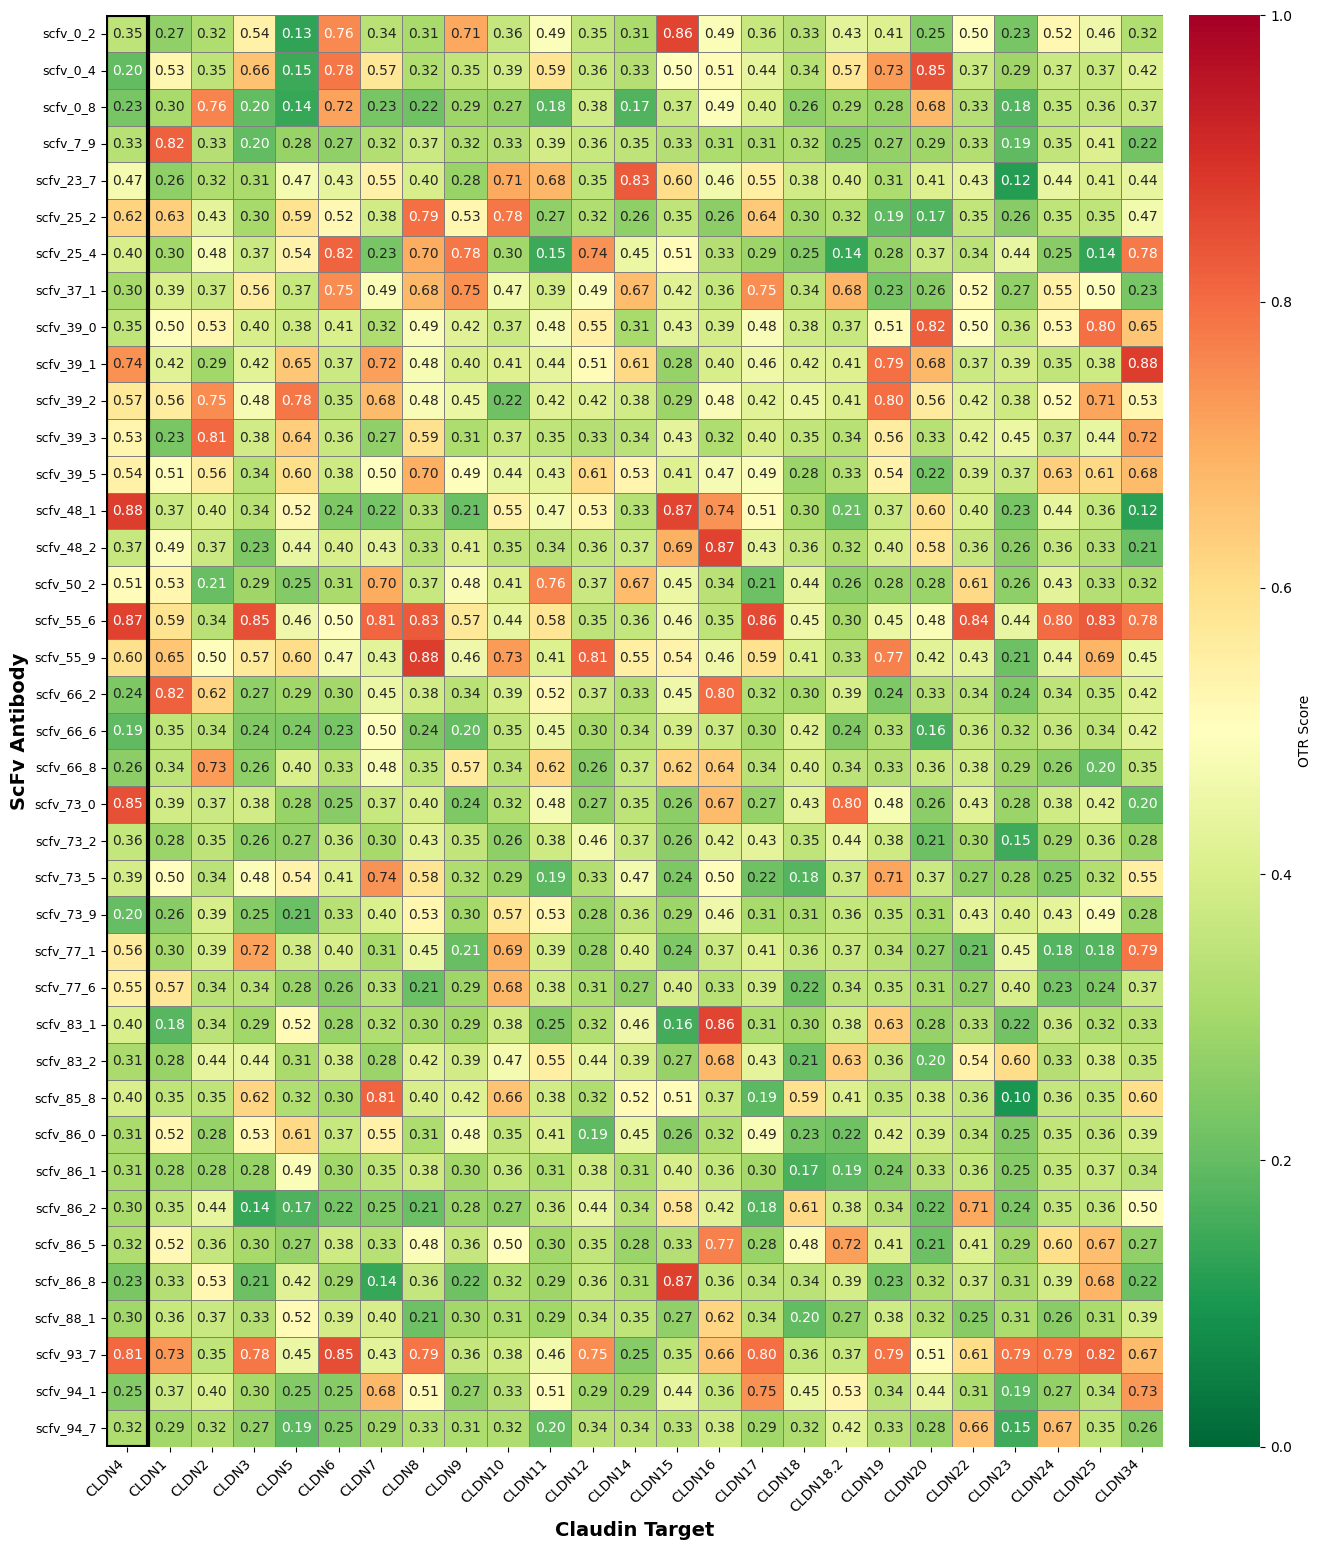


📊 İSTATİSTİKSEL ÖZET

CLDN4 (ON-TARGET) Skorları:
   Mean: 0.429
   Median: 0.356
   Min: 0.191
   Max: 0.877

OFF-TARGET Skorları:
   Mean: 0.408
   Median: 0.366
   Min: 0.099
   Max: 0.878

🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ScFv (CLDN4 / Avg_OffTarget)
     ScFv  CLDN4_Score  Avg_OffTarget  Max_OffTarget  R_Specificity
scfv_73_0     0.846345       0.374185       0.797989       2.261833
scfv_48_1     0.876515       0.402529       0.866345       2.177519
scfv_77_6     0.549847       0.337503       0.680961       1.629162
scfv_39_1     0.743094       0.480452       0.876917       1.546656
scfv_25_2     0.624615       0.409522       0.793396       1.525228

⚠️  EN YÜKSEK OFF-TARGET BAĞLANMASI OLAN 5 ScFv
     ScFv  CLDN4_Score  Max_OffTarget  R_Specificity
scfv_55_9     0.596556       0.877808       1.118121
scfv_39_1     0.743094       0.876917       1.546656
scfv_86_8     0.233051       0.873871       0.650800
scfv_48_2     0.366363       0.868463       0.906722
scfv_48_1     0.876515

In [ ]:
# @title Heatmap (Supp. Figure S3)
# @markdown Tüm ScFv'lerin CLDN4 (ON-TARGET) ve diğer Claudinlere (OFF-TARGET) bağlanma skorlarını gösterir.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- DOSYA YOLLARI ---
CONFIG = {
    "on_target_csv": "/home/ozangocmen/RFantibody/CLDN4/output_CLDN4/OTR_ontarget/OTR_ontarget.csv",
    "off_target_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget/OTR_offtarget_test1.csv",
    "output_heatmap": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/scfv_claudin_heatmap_test2.png",
    "output_heatmap": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/scfv_claudin_heatmap_test2.pdf",
    "output_data": "/home/ozangocmen/RFantibody/CLDN4/FINAL_CANDIDATES/scfv_claudin_matrix_test2.csv"
}

# --- FONKSİYONLAR ---

def extract_scfv_id(sample_id):
    """ScFv ID'yi çıkarır: scfv_X_Y"""
    match = re.search(r'(scfv_\d+_\d+)', str(sample_id))
    if match:
        return match.group(1)
    return None

def extract_claudin_name(sample_id):
    """
    OFF-TARGET'tan Claudin ismini çıkarır.
    Örnekler:
    - scfv_0_2_vs_cld10_human -> CLDN10
    - scfv_0_8_vs_cld18_2_human -> CLDN18.2
    """
    match = re.search(r'vs_(cld\d+(?:_\d+)?)', str(sample_id))
    if match:
        cldn = match.group(1).upper().replace('CLD', 'CLDN').replace('_', '.')
        return cldn
    return None

def sort_claudins(claudin_list):
    """Claudinleri doğal sıralama ile sıralar: CLDN1, CLDN2, ..., CLDN18.2, ..."""
    def claudin_key(cldn):
        if '.' in cldn:
            # CLDN18.2 gibi
            parts = cldn.replace('CLDN', '').split('.')
            return (int(parts[0]), int(parts[1]))
        else:
            # CLDN10 gibi
            return (int(cldn.replace('CLDN', '')), 0)
    
    return sorted(claudin_list, key=claudin_key)

def sort_scfvs(scfv_list):
    """ScFv'leri numerik olarak sıralar: scfv_0_2, scfv_0_4, ..., scfv_93_7"""
    def scfv_key(scfv):
        match = re.search(r'scfv_(\d+)_(\d+)', scfv)
        if match:
            return (int(match.group(1)), int(match.group(2)))
        return (999, 999)
    
    return sorted(scfv_list, key=scfv_key)

# --- ANA AKIŞ ---
print("="*80)
print("🔥 ScFv vs Claudin Family - OTR Score Heatmap Generator")
print("="*80)

# 1. Verileri Yükle
print("\n📊 Veriler yükleniyor...")
df_on = pd.read_csv(CONFIG["on_target_csv"])
df_off = pd.read_csv(CONFIG["off_target_csv"])

print(f"   ✅ ON-TARGET: {len(df_on)} model")
print(f"   ✅ OFF-TARGET: {len(df_off)} model")

# 2. ScFv ve Claudin ID'lerini Çıkar
print("\n🔍 ID'ler çıkarılıyor...")

# ON-TARGET (CLDN4)
df_on['ScFv_ID'] = df_on['Sample_ID'].apply(extract_scfv_id)
df_on['Claudin'] = 'CLDN4'
df_on_subset = df_on[['ScFv_ID', 'Claudin', 'Scientific_Score']].copy()
df_on_subset.rename(columns={'Scientific_Score': 'OTR_Score'}, inplace=True)

# OFF-TARGET (Diğer Claudinler)
df_off['ScFv_ID'] = df_off['Sample_ID'].apply(extract_scfv_id)
df_off['Claudin'] = df_off['Sample_ID'].apply(extract_claudin_name)
df_off_subset = df_off[['ScFv_ID', 'Claudin', 'Scientific_Score']].copy()
df_off_subset.rename(columns={'Scientific_Score': 'OTR_Score'}, inplace=True)

# Null olanları temizle
df_on_subset = df_on_subset.dropna(subset=['ScFv_ID', 'Claudin'])
df_off_subset = df_off_subset.dropna(subset=['ScFv_ID', 'Claudin'])

# 3. Birleştir
print("\n🔗 Veriler birleştiriliyor...")
df_combined = pd.concat([df_on_subset, df_off_subset], ignore_index=True)

print(f"   Toplam veri noktası: {len(df_combined)}")
print(f"   Benzersiz ScFv: {df_combined['ScFv_ID'].nunique()}")
print(f"   Benzersiz Claudin: {df_combined['Claudin'].nunique()}")

# 4. Pivot Table Oluştur (ScFv x Claudin Matrix)
print("\n📐 Matris oluşturuluyor...")
pivot_matrix = df_combined.pivot_table(
    index='ScFv_ID',
    columns='Claudin',
    values='OTR_Score',
    aggfunc='first'  # Eğer duplicate varsa ilkini al
)

# Sıralama
all_claudins = pivot_matrix.columns.tolist()
sorted_claudins = sort_claudins(all_claudins)

# CLDN4'ü başa al
if 'CLDN4' in sorted_claudins:
    sorted_claudins.remove('CLDN4')
    sorted_claudins = ['CLDN4'] + sorted_claudins

pivot_matrix = pivot_matrix[sorted_claudins]

# ScFv'leri sırala
all_scfvs = pivot_matrix.index.tolist()
sorted_scfvs = sort_scfvs(all_scfvs)
pivot_matrix = pivot_matrix.reindex(sorted_scfvs)

print(f"   Matris boyutu: {pivot_matrix.shape[0]} ScFv x {pivot_matrix.shape[1]} Claudin")

# Matrisi CSV olarak kaydet
pivot_matrix.to_csv(CONFIG["output_data"])
print(f"   ✅ Matris verisi kaydedildi: {CONFIG['output_data']}")

# 5. Heatmap Çiz
print("\n🎨 Heatmap oluşturuluyor...")

# Figür boyutu (Claudin sayısına göre dinamik)
n_claudins = pivot_matrix.shape[1]
n_scfvs = pivot_matrix.shape[0]

fig_width = max(14, n_claudins * 0.5)
fig_height = max(10, n_scfvs * 0.4)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Heatmap çiz
sns.heatmap(
    pivot_matrix,
    annot=True,           # Her hücreye değer yaz
    fmt='.2f',            # 2 ondalık basamak
    cmap='RdYlGn_r',        # Kırmızı (düşük) -> Sarı -> Yeşil (yüksek)
    center=0.5,           # Ortalamanın rengini belirle
    vmin=0,               # Minimum değer
    vmax=1.0,             # Maximum değer
    cbar_kws={
        'label': 'OTR Score',
        'orientation': 'vertical',
        'pad': 0.02
    },
    linewidths=0.5,       # Hücre arası çizgi
    linecolor='gray',
    ax=ax
)

# CLDN4 sütununu vurgula (ON-TARGET)
if 'CLDN4' in pivot_matrix.columns:
    cldn4_idx = pivot_matrix.columns.get_loc('CLDN4')
    ax.add_patch(plt.Rectangle((cldn4_idx, 0), 1, n_scfvs, 
                               fill=False, edgecolor='black', lw=3))

# Etiketler
ax.set_xlabel('Claudin Target', fontsize=14, fontweight='bold')
ax.set_ylabel('ScFv Antibody', fontsize=14, fontweight='bold')

# Eksen etiketlerini döndür
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=9)

# Layout ayarı
plt.tight_layout()

# Kaydet
output_dir = os.path.dirname(CONFIG["output_heatmap"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

plt.savefig(CONFIG["output_heatmap"], dpi=300, bbox_inches='tight')
print(f"   ✅ Heatmap kaydedildi: {CONFIG['output_heatmap']}")

plt.show()

# 6. İstatistiksel Özet
print("\n" + "="*80)
print("📊 İSTATİSTİKSEL ÖZET")
print("="*80)

# Her ScFv için ON-TARGET vs OFF-TARGET karşılaştırması
cldn4_scores = pivot_matrix['CLDN4'].dropna()
off_target_cols = [c for c in pivot_matrix.columns if c != 'CLDN4']

print(f"\nCLDN4 (ON-TARGET) Skorları:")
print(f"   Mean: {cldn4_scores.mean():.3f}")
print(f"   Median: {cldn4_scores.median():.3f}")
print(f"   Min: {cldn4_scores.min():.3f}")
print(f"   Max: {cldn4_scores.max():.3f}")

if len(off_target_cols) > 0:
    off_target_scores = pivot_matrix[off_target_cols].values.flatten()
    off_target_scores = off_target_scores[~np.isnan(off_target_scores)]
    
    print(f"\nOFF-TARGET Skorları:")
    print(f"   Mean: {off_target_scores.mean():.3f}")
    print(f"   Median: {np.median(off_target_scores):.3f}")
    print(f"   Min: {off_target_scores.min():.3f}")
    print(f"   Max: {off_target_scores.max():.3f}")

# En iyi spesifikliğe sahip ScFv'ler
print("\n" + "="*80)
print("🌟 EN YÜKSEK SPESİFİKLİĞE SAHİP 5 ScFv (CLDN4 / Avg_OffTarget)")
print("="*80)

specificity_scores = []
for scfv in pivot_matrix.index:
    cldn4_score = pivot_matrix.loc[scfv, 'CLDN4']
    
    if pd.notna(cldn4_score):
        off_scores = pivot_matrix.loc[scfv, off_target_cols].dropna()
        
        if len(off_scores) > 0:
            avg_off = off_scores.mean()
            max_off = off_scores.max()
            r_spec = cldn4_score / avg_off if avg_off > 0 else 100
            
            specificity_scores.append({
                'ScFv': scfv,
                'CLDN4_Score': cldn4_score,
                'Avg_OffTarget': avg_off,
                'Max_OffTarget': max_off,
                'R_Specificity': r_spec
            })

spec_df = pd.DataFrame(specificity_scores).sort_values('R_Specificity', ascending=False)
print(spec_df.head(5).to_string(index=False))

# En kötü OFF-TARGET bağlanması olan ScFv'ler
print("\n" + "="*80)
print("⚠️  EN YÜKSEK OFF-TARGET BAĞLANMASI OLAN 5 ScFv")
print("="*80)

worst_off_df = spec_df.sort_values('Max_OffTarget', ascending=False)
print(worst_off_df.head(5)[['ScFv', 'CLDN4_Score', 'Max_OffTarget', 'R_Specificity']].to_string(index=False))

# Her Claudin için ortalama bağlanma
print("\n" + "="*80)
print("🎯 CLAUDIN BAZINDA ORTALAMA OTR SKORLARI")
print("="*80)

claudin_means = pivot_matrix.mean(axis=0).sort_values(ascending=False)
print("En Çok Bağlanan Claudinler:")
for cldn, score in claudin_means.head(10).items():
    if cldn == 'CLDN4':
        print(f"   {cldn}: {score:.3f} ⭐ (ON-TARGET)")
    else:
        print(f"   {cldn}: {score:.3f}")

print("\n" + "="*80)
print("✅ HEATmap ANALİZİ TAMAMLANDI!")
print("="*80)
print(f"📊 Heatmap: {CONFIG['output_heatmap']}")
print(f"📁 Matris CSV: {CONFIG['output_data']}")